# Exploração de Dados Públicos com Estatística Descritiva
- Aluno: Pedro Yutaro Mont Morency Nakamura
- Disciplina: Ciência de Dados
- Data: Fervereiro de 2026

# 1. Sobre o Dataset
- Nome do dataset: Microdados do Censo Escolar da Educacação Básica (2025);
- Link: https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-escolar;
- Órgão responsável pela publicação: INEP;

## 1.1 Tema:
O dataset Microdados do Censo Escolar 2025, especificamente a Tabela_Escola_2025.csv, reúne informações sobre as escolas de educação básica em todo o território brasileiro.


## 1.1 Finalidade:
Esse conjunto de dados tem como objetivo fornecer uma visão abrangente da estrutura educacional do país, permitindo a análise de aspectos como distribuição geográfica das escolas, dependência administrativa (pública ou privada), localização (urbana ou rural) e características institucionais. Ele é utilizado para subsidiar políticas públicas, planejamento educacional e estudos estatísticos sobre a educação no Brasil.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carregamento dos Dados

In [5]:
file = './microdados_censo_escolar_2025/Tabela_Escola_2025.csv'
df = pd.read_csv(file, encoding='latin1', sep=';', low_memory=False)
df.head()

,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,IN_ESP_EXCLUSIVA_MEDIO_FIC,IN_ESP_EXCLUSIVA_MEDIO_NORMAL,IN_COMUM_EJA_FUND,IN_COMUM_EJA_MEDIO,IN_COMUM_EJA_PROF,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_COMUM_PROF,IN_ESP_EXCLUSIVA_PROF
0,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025,Norte,1,Rondônia,RO,11,Alta Floresta D'Oeste,1100015,Ji-Paraná,1102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2.1 Descrição do Dataset:

### Número de Registros e Colunas

In [ ]:
# estrutura do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214192 entries, 0 to 214191
Columns: 302 entries, NU_ANO_CENSO to IN_ESP_EXCLUSIVA_PROF
dtypes: float64(270), int64(14), str(18)
memory usage: 493.5 MB


### Tipo das variáveis

In [7]:
# Tipos de dados
tipos = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo de dado': df.dtypes.values
})

tipos

,Coluna,Tipo de dado
0,NU_ANO_CENSO,int64
1,NO_REGIAO,str
2,CO_REGIAO,int64
3,NO_UF,str
4,SG_UF,str
...,...,...
297,IN_ESP_EXCLUSIVA_EJA_FUND,float64
298,IN_ESP_EXCLUSIVA_EJA_MEDIO,float64
299,IN_ESP_EXCLUSIVA_EJA_PROF,float64
300,IN_COMUM_PROF,float64


## 2.2 Significado das Variáveis importantes

A interpretação das variáveis foi realizada com base no dicionário de dados disponibilizado pelo INEP.

Algumas variáveis relevantes da tabela Tabela_Escola_2025.csv incluem:

- CO_ENTIDADE: Código único de identificação da escola no sistema do Censo Escolar.
- NO_ENTIDADE: Nome da escola.
- SG_UF: Sigla da unidade federativa (estado) onde a escola está localizada.
- CO_MUNICIPIO: Código do município da escola.
- TP_DEPENDENCIA: Tipo de dependência administrativa da escola:
  - 1 = Federal
  - 2 = Estadual
  - 3 = Municipal
  - 4 = Privada
- TP_LOCALIZACAO: Localização da escola:
  - 1 = Urbana
  - 2 = Rural

- TP_SITUACAO_FUNCIONAMENTO: Situação de funcionamento da escola (ativa, paralisada, extinta, etc.)
- IN_AGUA_POTAVEL: Indica se a escola possui acesso à água potável (1 = Sim, 0 = Não)
- IN_ENERGIA_REDE_PUBLICA: Indica se a escola possui energia elétrica da rede pública

# 3 Exploração Estatística no Notebook

In [8]:
# Valores ausêntes
df.isnull().sum()

NU_ANO_CENSO                      0
NO_REGIAO                         0
CO_REGIAO                         0
NO_UF                             0
SG_UF                             0
                              ...  
IN_ESP_EXCLUSIVA_EJA_FUND     33652
IN_ESP_EXCLUSIVA_EJA_MEDIO    33652
IN_ESP_EXCLUSIVA_EJA_PROF     33652
IN_COMUM_PROF                 33652
IN_ESP_EXCLUSIVA_PROF         33652
Length: 302, dtype: int64

## 3.1 Tratamento inicial dos dados

In [10]:
# Ajustando nome das colunas
df.columns = df.columns.str.strip()

# Filtrando colunas mais relevantes para análise
colunas_utilizadas = [
    'SG_UF',
    'TP_DEPENDENCIA',
    'TP_LOCALIZACAO',
    'TP_SITUACAO_FUNCIONAMENTO'
]

df_sel = df[colunas_utilizadas]
df_sel.head()

,SG_UF,TP_DEPENDENCIA,TP_LOCALIZACAO,TP_SITUACAO_FUNCIONAMENTO
0,RO,2,2,1
1,RO,2,1,1
2,RO,3,2,2
3,RO,3,2,1
4,RO,2,1,1


### Tratando valores Categóricos

In [11]:
# Dependência administrativa
map_dependencia = {
    1: 'Federal',
    2: 'Estadual',
    3: 'Municipal',
    4: 'Privada'
}

df_sel['TP_DEPENDENCIA'] = df_sel['TP_DEPENDENCIA'].map(map_dependencia)

# Localização
map_localizacao = {
    1: 'Urbana',
    2: 'Rural'
}

df_sel['TP_LOCALIZACAO'] = df_sel['TP_LOCALIZACAO'].map(map_localizacao)

map_situacao = {
    1: 'Em funcionamento',
    2: 'Paralisada',
    3: 'Extinta',
    4: 'Em implantação'
}

df_sel['TP_SITUACAO_FUNCIONAMENTO'] = df_sel['TP_SITUACAO_FUNCIONAMENTO'].map(map_situacao)

# 4. Visualização dos Dados

## 4.1 Distribuição de escolas por Estado

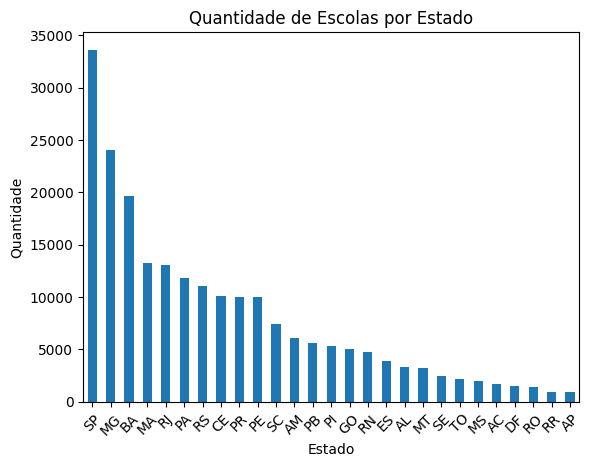

In [12]:
uf_counts = df_sel['SG_UF'].value_counts()

plt.figure()
uf_counts.plot(kind='bar')
plt.title('Quantidade de Escolas por Estado')
plt.xlabel('Estado')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.show()

## 4.2 Distribuição de escolas por Tipo

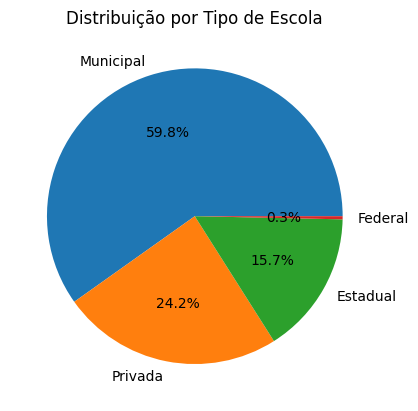

In [13]:
dep_counts = df_sel['TP_DEPENDENCIA'].value_counts()

plt.figure()
dep_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribuição por Tipo de Escola')
plt.ylabel('')
plt.show()

## 4.3 Escola Urbana VS Escola Rural

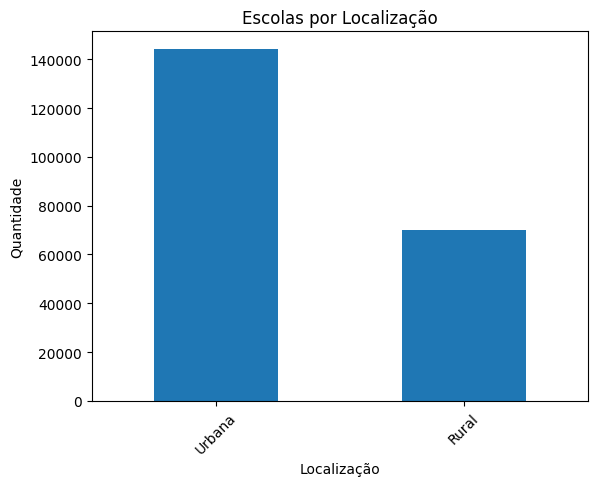

In [14]:
loc_counts = df_sel['TP_LOCALIZACAO'].value_counts()

plt.figure()
loc_counts.plot(kind='bar')
plt.title('Escolas por Localização')
plt.xlabel('Localização')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

plt.show()

## 4.4 Situação de Funcionamento

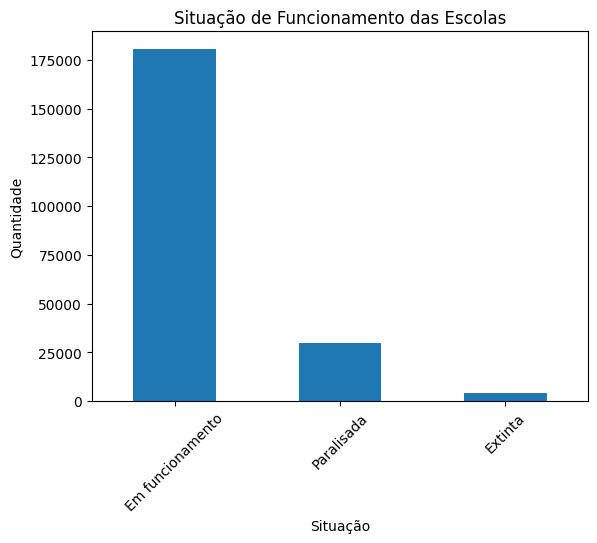

In [15]:
sit_counts = df_sel['TP_SITUACAO_FUNCIONAMENTO'].value_counts()

plt.figure()
sit_counts.plot(kind='bar')
plt.title('Situação de Funcionamento das Escolas')
plt.xlabel('Situação')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

plt.show()

## 4.4 Tipo de Escola por Estado

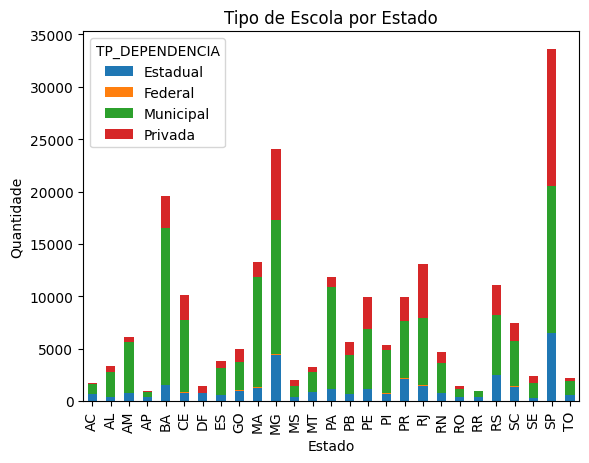

In [16]:
cross = pd.crosstab(df_sel['SG_UF'], df_sel['TP_DEPENDENCIA'])

cross.plot(kind='bar', stacked=True)
plt.title('Tipo de Escola por Estado')
plt.xlabel('Estado')
plt.ylabel('Quantidade')
plt.show()

# 5. Estatística Descritiva

Como o dataset é marjoritariamente cetegórico, para a extração das estatísticas descritivas será necessário converter categorias em números úteis.

Um exemplo disso é podermos averiguar o número de escolas por estado, como segue:

In [17]:
escolas_por_estado = df['SG_UF'].value_counts()

## 5.1 Média, mediana e moda de Escolas por Estado 

In [18]:
# Média
mean = escolas_por_estado.mean()

# Mediana
median = escolas_por_estado.median()

# Moda
mode = escolas_por_estado.mode().iloc[0]

print(f'Média de escola por estado: {mean:.2f};')
print(f'Mediana de escola por estado: {median:.2f};')
print(f'Moda de escola por estado: {mode};')

Média de escola por estado: 7933.04;
Mediana de escola por estado: 5325.00;
Moda de escola por estado: 944;


## 5.2 Mínimo, Máximo e Desvio Padrão de Escolas por Estado 

In [19]:
# Mínimo e Máximo
min_ = escolas_por_estado.min()
max_ = escolas_por_estado.max()

# Desvio padrão e variância
std = escolas_por_estado.std()
var = escolas_por_estado.var()

print(f'Mínimo de escola por estado: {min_:.2f};')
print(f'Máximo de escola por estado: {max_:.2f};')
print(f'Desvio padrão de escola por estado: {std:.2f};')
print(f'Variância de escola por estado: {var:.2f};')

Mínimo de escola por estado: 944.00;
Máximo de escola por estado: 33616.00;
Desvio padrão de escola por estado: 7751.44;
Variância de escola por estado: 60084795.81;


## 5.3 Quartis e intervalo interquartil (IQR)

In [20]:
# Quartis
Q1 = escolas_por_estado.quantile(0.25)
Q2 = escolas_por_estado.quantile(0.50)
Q3 = escolas_por_estado.quantile(0.75)
IQR = Q3 - Q1
print(f'Q1: {Q1:.2f};')
print(f'Q2: {Q2:.2f};')
print(f'Q3: {Q3:.2f};')
print(f'IQR: {IQR:.2f};')

Q1: 2323.50;
Q2: 5325.00;
Q3: 10584.00;
IQR: 8260.50;


## 5.5 Histograma de Escola por Estado

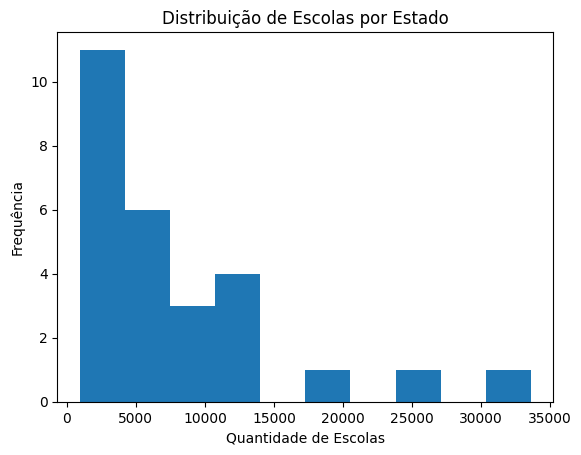

In [22]:
plt.figure()
escolas_por_estado.plot(kind='hist')
plt.title('Distribuição de Escolas por Estado')
plt.xlabel('Quantidade de Escolas')
plt.ylabel('Frequência')
plt.show()

## 5.6 Boxplot de Escola por Estado

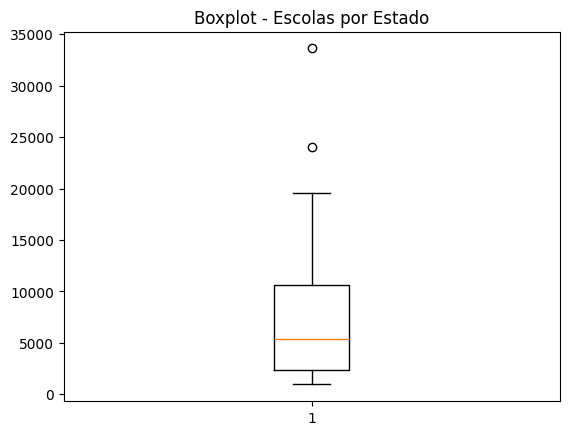

In [21]:
plt.figure()
plt.boxplot(escolas_por_estado)
plt.title('Boxplot - Escolas por Estado')
plt.show()

## 5.7 Dispersão de Escolas por Estado

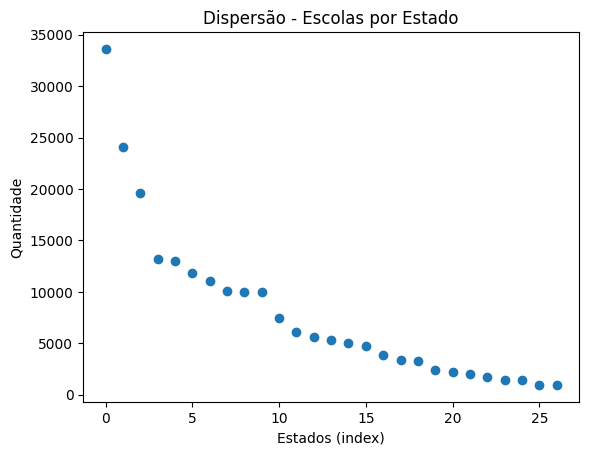

In [23]:
# Exemplo: índice vs quantidade
x = range(len(escolas_por_estado))
y = escolas_por_estado.values

plt.figure()
plt.scatter(x, y)
plt.title('Dispersão - Escolas por Estado')
plt.xlabel('Estados (index)')
plt.ylabel('Quantidade')
plt.show()

# 6. Análise e Comentários
A análise descritiva da quantidade de escolas por estado revelou uma distribuição desigual entre as unidades federativas.

A média indica o número médio de escolas por estado, enquanto a mediana mostra o valor central da distribuição. A diferença entre esses valores sugere a presença de assimetria nos dados.

O desvio padrão elevado indica grande variabilidade na quantidade de escolas entre os estados, evidenciando desigualdades regionais.

O boxplot permitiu identificar possíveis valores extremos (outliers), correspondentes a estados com número significativamente maior ou menor de escolas.